<a href="https://colab.research.google.com/github/vedantjoshi24-alt/Deep_Learning/blob/main/Assignment_02/DL_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
RANDOM_STATE = 42

Shape: (178, 13)
Class balance:
 target
0    59
1    71
2    48
Name: count, dtype: int64


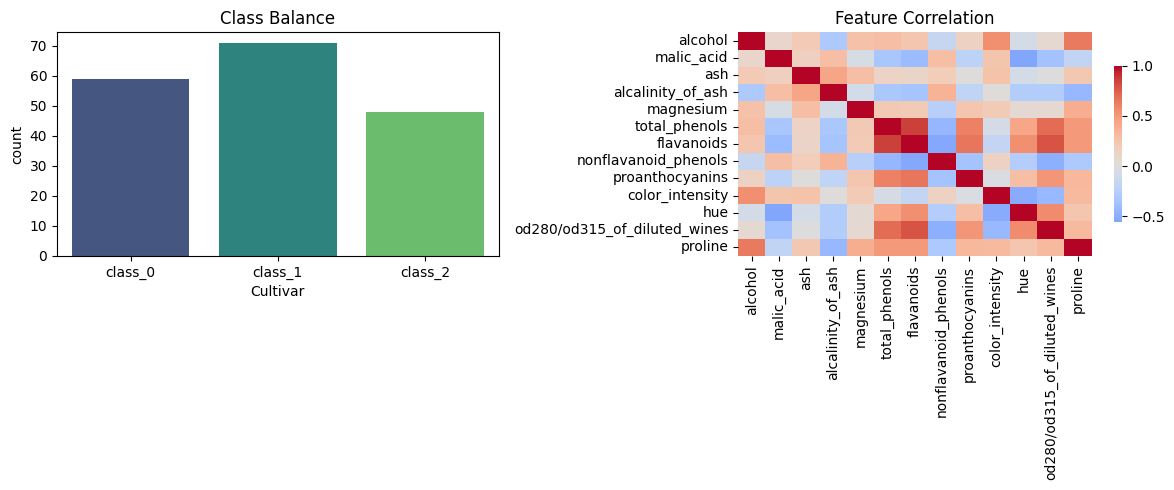

In [ ]:
# 1. Load Data + EDA
wine = datasets.load_wine()
X, y = wine.data, wine.target
class_names = wine.target_names
df = pd.DataFrame(X, columns=wine.feature_names)
df["target"] = y

print("Shape:", X.shape)
print("Class balance:\n", df["target"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=df["target"].map(dict(enumerate(class_names))), ax=axes[0],
              hue=df["target"].map(dict(enumerate(class_names))),
              palette="viridis", legend=False)
axes[0].set_title("Class Balance")
axes[0].set_xlabel("Cultivar")

corr = df.drop(columns="target").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=axes[1], cbar_kws={"shrink": 0.7})
axes[1].set_title("Feature Correlation")
plt.tight_layout()
plt.show()

In [ ]:
# 2. Train/test splits
splits = {
    "70/30 split": train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y),
    "90/10 split": train_test_split(X, y, test_size=0.1, random_state=RANDOM_STATE, stratify=y),
}

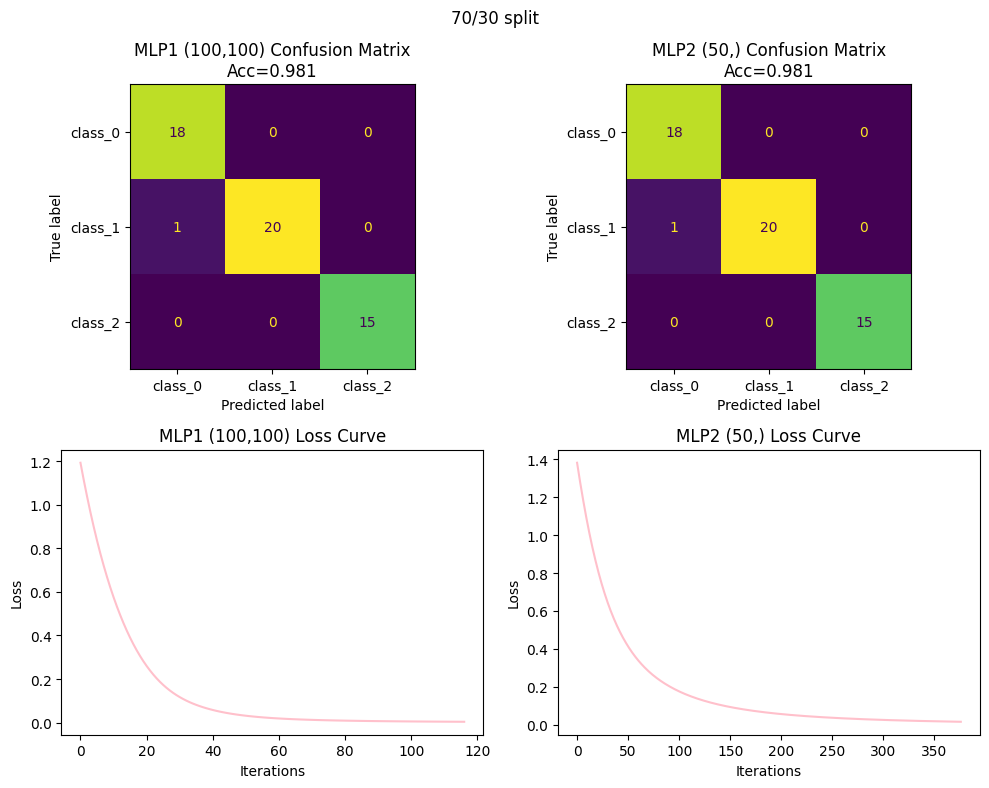

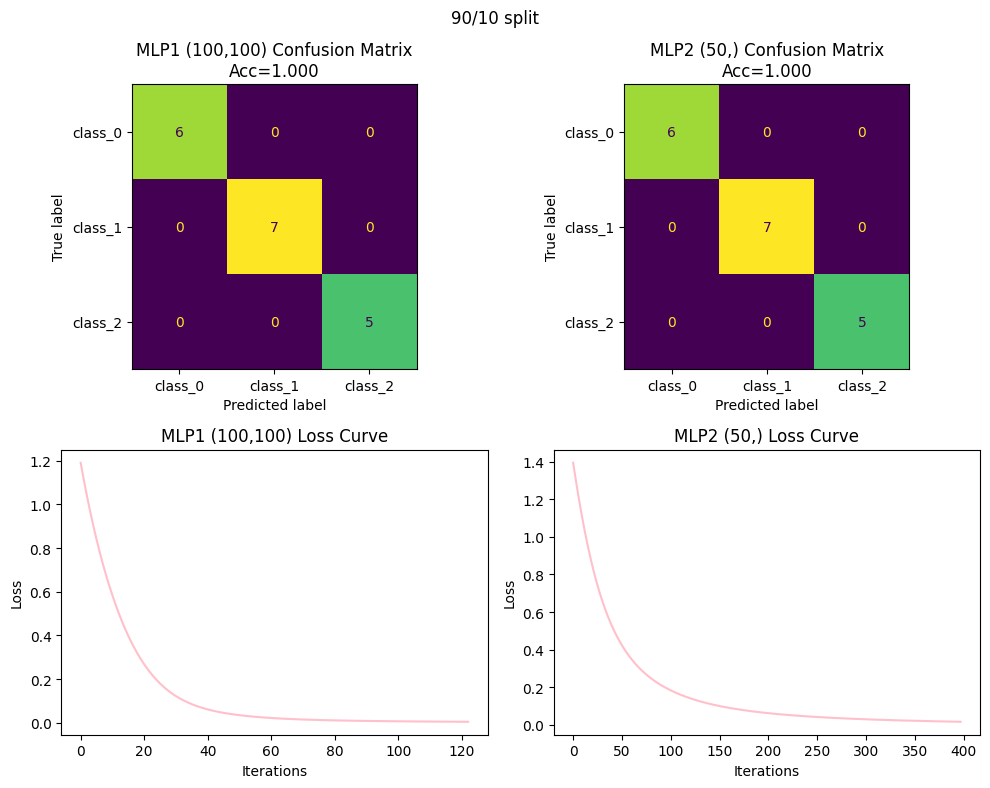


=== Summary table ===
   Scenario          Model  Accuracy     F1  Precision  Recall  CV F1 Mean  CV F1 Std
70/30 split MLP1 (100,100)    0.9815 0.9815     0.9825  0.9815      0.9923     0.0231
70/30 split     MLP2 (50,)    0.9815 0.9815     0.9825  0.9815      0.9841     0.0318
90/10 split MLP1 (100,100)    1.0000 1.0000     1.0000  1.0000      0.9938     0.0188
90/10 split     MLP2 (50,)    1.0000 1.0000     1.0000  1.0000      0.9685     0.0510


In [ ]:
# 3. MLP Architectures
def make_models():
    return {
        "MLP1 (100,100)": MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000,
                                         learning_rate_init=0.001, random_state=RANDOM_STATE),
        "MLP2 (50,)": MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000,
                                     learning_rate_init=0.001, random_state=RANDOM_STATE),
    }

results = []

def evaluate_scenario(scenario_name, X_train, X_test, y_train, y_test):
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    models = make_models()

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for i, (name, model) in enumerate(models.items()):
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=1)
        rec = recall_score(y_test, y_pred, average="weighted")

        cv_scores = cross_val_score(model, X_train_s, y_train, cv=10, scoring="f1_weighted")

        results.append({
            "Scenario": scenario_name, "Model": name,
            "Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec,
            "CV F1 Mean": cv_scores.mean(), "CV F1 Std": cv_scores.std(),
        })

        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=axes[0, i], cmap="viridis", values_format="d", colorbar=True)
        axes[0, i].set_title(f"{name} Confusion Matrix\nAcc={acc:.3f}")

        axes[1, i].plot(model.loss_curve_, color="red")
        axes[1, i].set_title(f"{name} Loss Curve")
        axes[1, i].set_xlabel("Iterations")
        axes[1, i].set_ylabel("Loss")

    plt.suptitle(scenario_name)
    plt.tight_layout()
    plt.show()

for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    evaluate_scenario(name, X_tr, X_te, y_tr, y_te)

results_df = pd.DataFrame(results)
print("\n=== Summary table ===")
print(results_df.round(4).to_string(index=False))

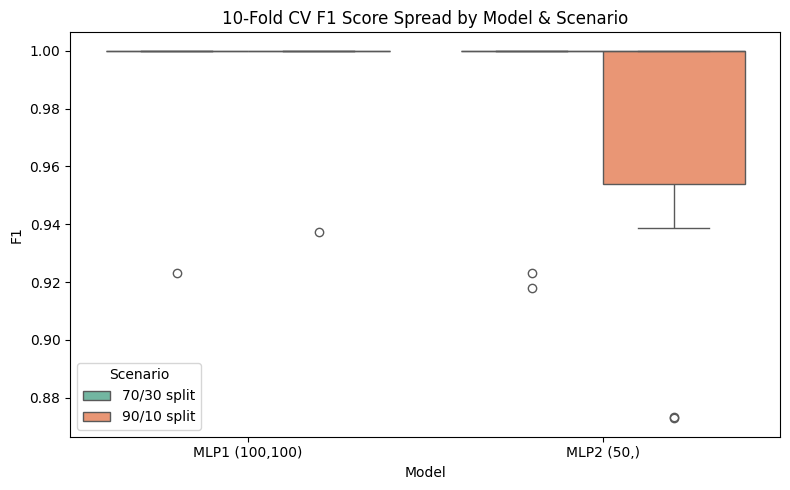

In [ ]:
# 4. Boxplot
cv_records = []
for scenario_name, (X_tr, X_te, y_tr, y_te) in splits.items():
    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    for name, model in make_models().items():
        scores = cross_val_score(model, X_tr_s, y_tr, cv=10, scoring="f1_weighted")
        for s in scores:
            cv_records.append({"Scenario": scenario_name, "Model": name, "F1": s})

cv_df = pd.DataFrame(cv_records)
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, x="Model", y="F1", hue="Scenario", palette="Set2")
plt.title("10-Fold CV F1 Score Spread by Model & Scenario")
plt.tight_layout()
plt.show()

In [ ]:
# 5. Comparison
print("\n=== 70/30 vs 90/10 comparison ===")
pivot = results_df.pivot(index="Model", columns="Scenario", values=["Accuracy", "F1"])
print(pivot.round(4))


=== 70/30 vs 90/10 comparison ===
                  Accuracy                      F1            
Scenario       70/30 split 90/10 split 70/30 split 90/10 split
Model                                                         
MLP1 (100,100)      0.9815         1.0      0.9815         1.0
MLP2 (50,)          0.9815         1.0      0.9815         1.0
